In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

emp_data = pd.read_csv(r"C:\Users\SAKSHI DAVE\Downloads\Dataset01-Employee_Attrition.csv")

In [3]:
emp_data.shape

(14999, 10)

In [4]:
emp_data.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [5]:
emp_data.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object

In [6]:
emp_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [7]:
emp_data[emp_data.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [9]:
emp_data1 =emp_data.drop_duplicates()
emp_data.shape


(14999, 10)

In [10]:
emp_data1.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [11]:
emp_data1['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

<Axes: xlabel='left'>

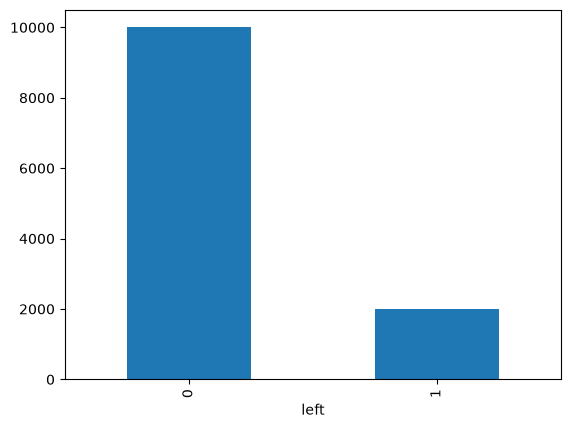

In [12]:
emp_data1['left'].value_counts().plot(kind= 'bar')

In [13]:
emp_data1.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [14]:
pd.crosstab(emp_data1.salary, emp_data1.left)

left,0,1
salary,,
high,942,48
low,4566,1174
medium,4492,769


<Axes: xlabel='salary'>

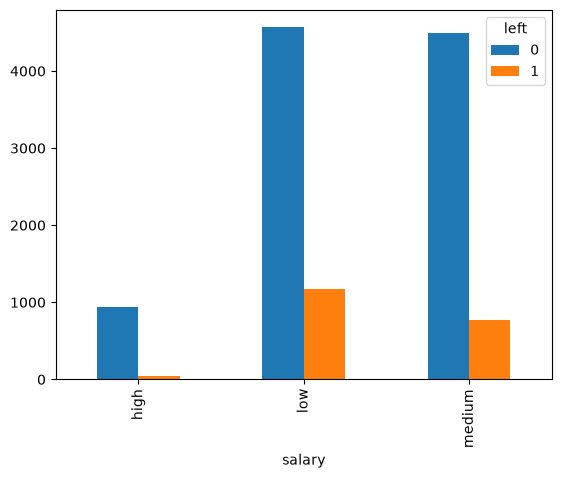

In [15]:
pd.crosstab(emp_data1.salary, emp_data1.left).plot(kind= 'bar')

Above bar chart shows that employees with higher salaries are not likely to leave

In [17]:
pd.crosstab(emp_data1.Department, emp_data1.left)

left,0,1
Department,,
IT,818,158
RandD,609,85
accounting,512,109
hr,488,113
management,384,52
marketing,561,112
product_mng,576,110
sales,2689,550
support,1509,312


<Axes: xlabel='Department'>

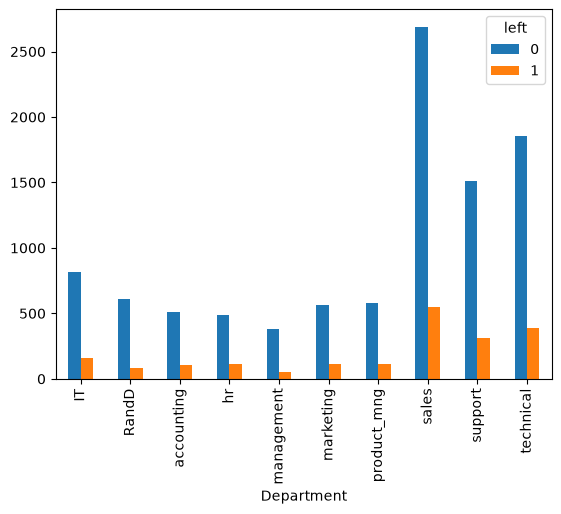

In [18]:
pd.crosstab(emp_data1.Department, emp_data1.left).plot(kind= 'bar')

In [19]:
num_feature_list1 = [f for f in emp_data1.columns if emp_data1.dtypes[f] == 'float64']
num_feature_list1

['satisfaction_level', 'last_evaluation']

In [20]:
num_feature_list2= [f for f in emp_data1.columns if emp_data1.dtypes[f] == 'int64']
num_feature_list2

['number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years']

In [21]:
num_col_list = ['number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years''satisfaction_level', 'last_evaluation']

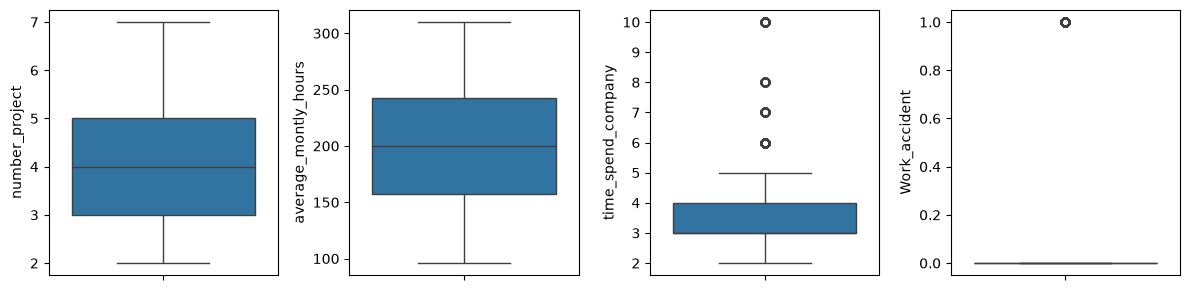

In [22]:
fig, axes = plt.subplots(ncols=4, figsize=(12, 3))

for column, axis in zip(num_col_list[:4], axes):
    sns.boxplot(data=emp_data1[column], ax=axis)

plt.tight_layout()
plt.show()

In [23]:
pd.crosstab(
    emp_data1['Department'],
    emp_data1['left']
)

left,0,1
Department,,
IT,818,158
RandD,609,85
accounting,512,109
hr,488,113
management,384,52
marketing,561,112
product_mng,576,110
sales,2689,550
support,1509,312


In [24]:
pd.crosstab(
    emp_data1['Department'],
    emp_data1['left'],
    normalize='index'
) * 100

left,0,1
Department,,
IT,83.811475,16.188525
RandD,87.752161,12.247839
accounting,82.447665,17.552335
hr,81.198003,18.801997
management,88.073394,11.926606
marketing,83.358098,16.641902
product_mng,83.965015,16.034985
sales,83.019450,16.980550
support,82.866557,17.133443


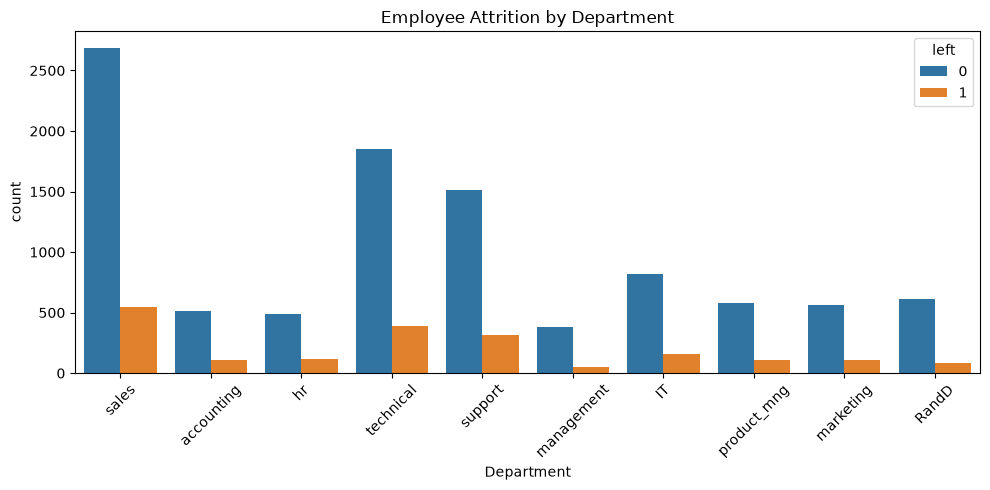

In [25]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=emp_data1,
    x='Department',
    hue='left'
)

plt.title("Employee Attrition by Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

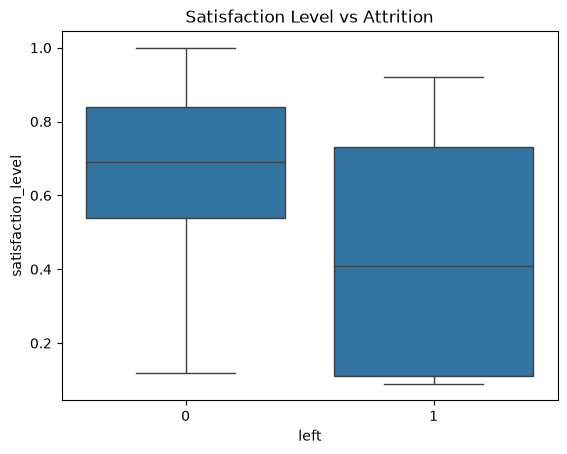

In [26]:
sns.boxplot(
    data=emp_data1,
    x='left',
    y='satisfaction_level'
)

plt.title("Satisfaction Level vs Attrition")
plt.show()

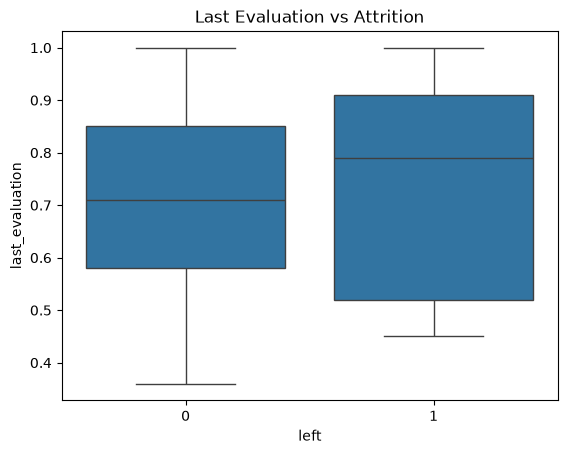

In [27]:
sns.boxplot(
    data=emp_data1,
    x='left',
    y='last_evaluation'
)

plt.title("Last Evaluation vs Attrition")
plt.show()

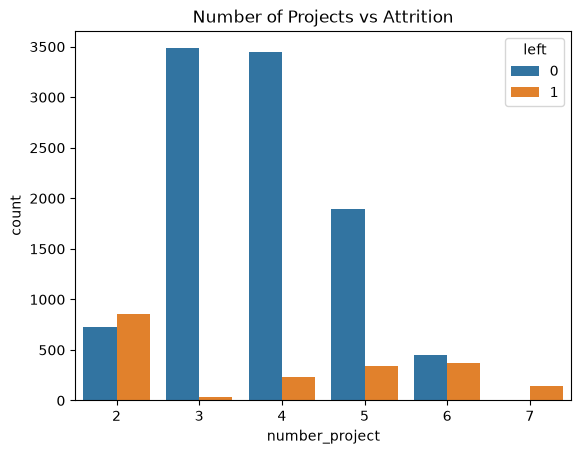

In [28]:
sns.countplot(
    data=emp_data1,
    x='number_project',
    hue='left'
)

plt.title("Number of Projects vs Attrition")
plt.show()

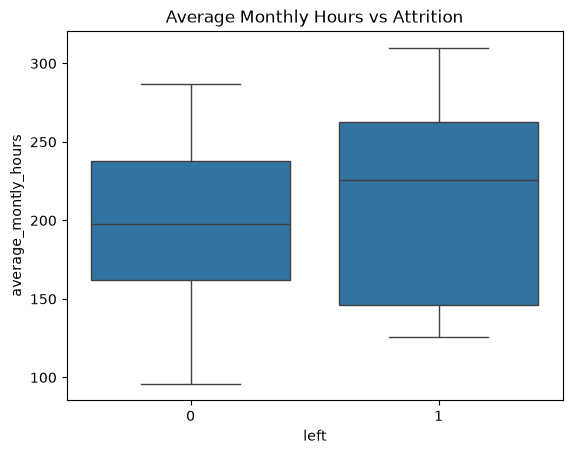

In [29]:
sns.boxplot(
    data=emp_data1,
    x='left',
    y='average_montly_hours'
)

plt.title("Average Monthly Hours vs Attrition")
plt.show()

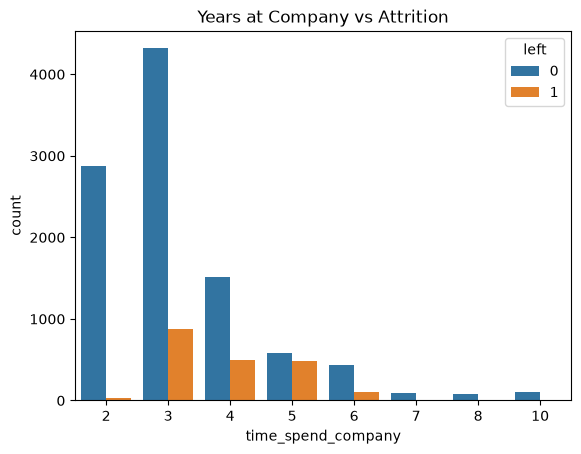

In [30]:
sns.countplot(
    data=emp_data1,
    x='time_spend_company',
    hue='left'
)

plt.title("Years at Company vs Attrition")
plt.show()

In [31]:
pd.crosstab(
    emp_data1['Work_accident'],
    emp_data1['left']
)

left,0,1
Work_accident,,
0,8255,1886
1,1745,105


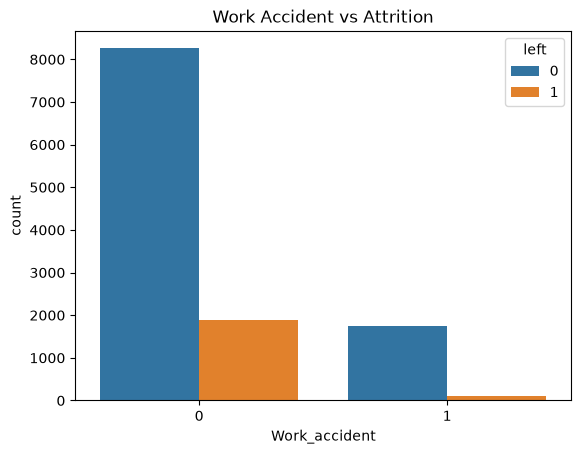

In [32]:
sns.countplot(
    data=emp_data1,
    x='Work_accident',
    hue='left'
)

plt.title("Work Accident vs Attrition")
plt.show()

In [34]:
pd.crosstab(
    emp_data1['promotion_last_5years'],
    emp_data1['left']
)

left,0,1
promotion_last_5years,,
0,9805,1983
1,195,8


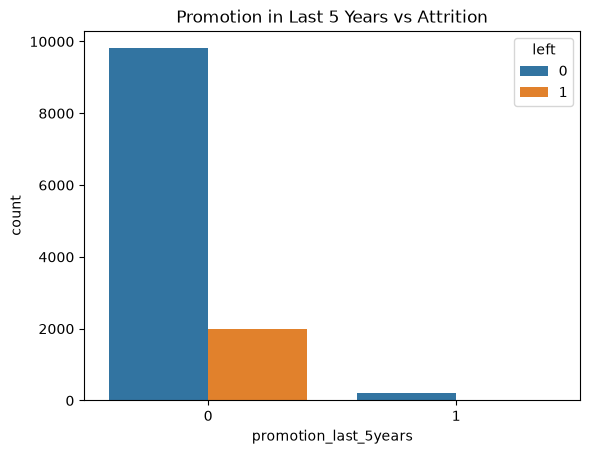

In [35]:
sns.countplot(
    data=emp_data1,
    x='promotion_last_5years',
    hue='left'
)

plt.title("Promotion in Last 5 Years vs Attrition")
plt.show()

In [36]:
correlation = emp_data1.select_dtypes(include='number').corr()

correlation

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.095186,-0.133246,-0.006252,-0.152915,0.039940,-0.350558,0.019789
last_evaluation,0.095186,1.000000,0.270256,0.264678,0.096829,-0.005695,0.013520,-0.007206
number_project,-0.133246,0.270256,1.000000,0.331516,0.188837,-0.005612,0.030928,-0.000544
average_montly_hours,-0.006252,0.264678,0.331516,1.000000,0.102875,-0.012860,0.070409,-0.004964
time_spend_company,-0.152915,0.096829,0.188837,0.102875,1.000000,0.000003,0.173295,0.056828
Work_accident,0.039940,-0.005695,-0.005612,-0.012860,0.000003,1.000000,-0.125436,0.029852
left,-0.350558,0.013520,0.030928,0.070409,0.173295,-0.125436,1.000000,-0.044657
promotion_last_5years,0.019789,-0.007206,-0.000544,-0.004964,0.056828,0.029852,-0.044657,1.000000


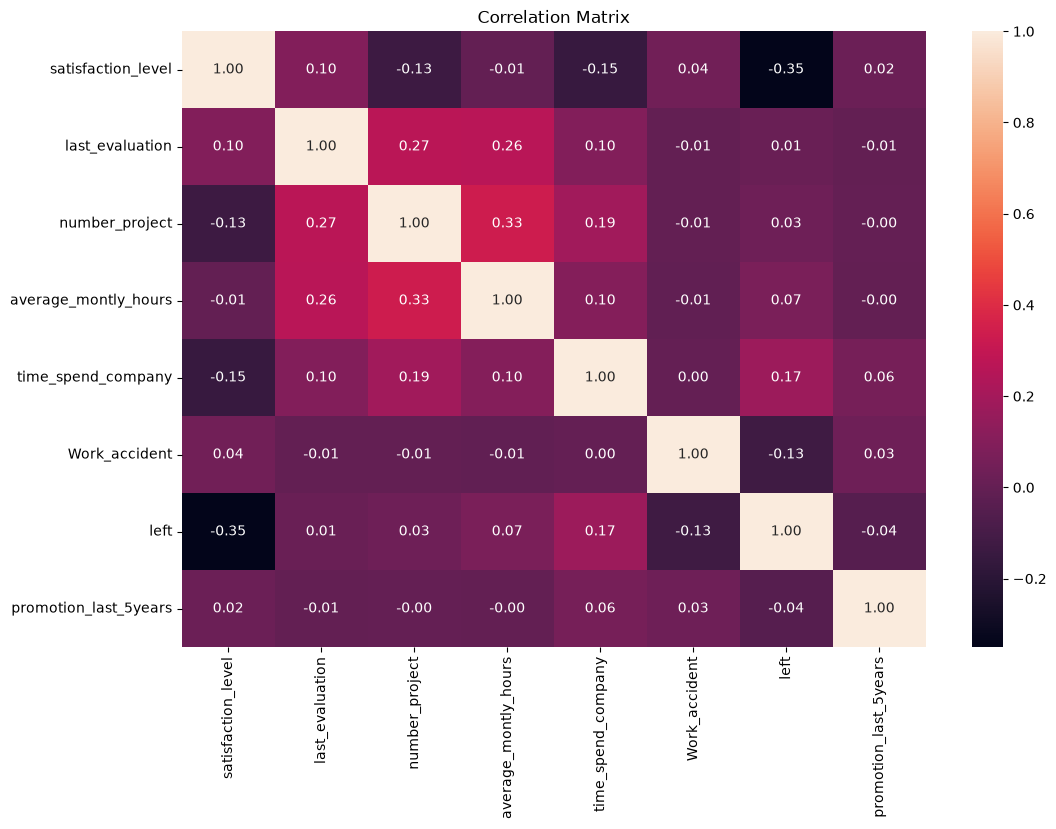

In [37]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

In [39]:
correlation = emp_data1.select_dtypes(include='number').corr()

correlation['left'].sort_values(ascending=False)

left                     1.000000
time_spend_company       0.173295
average_montly_hours     0.070409
number_project           0.030928
last_evaluation          0.013520
promotion_last_5years   -0.044657
Work_accident           -0.125436
satisfaction_level      -0.350558
Name: left, dtype: float64

In [40]:
emp_data1.groupby('left').mean(numeric_only=True).T

left,0,1
satisfaction_level,0.667365,0.440271
last_evaluation,0.715667,0.721783
number_project,3.786800,3.883476
average_montly_hours,198.942700,208.162230
time_spend_company,3.262000,3.881467
Work_accident,0.174500,0.052737
promotion_last_5years,0.019500,0.004018


In [41]:
department_attrition = (
    emp_data1
    .groupby('Department')['left']
    .mean()
    .sort_values(ascending=False)
    * 100
)

department_attrition

Department
hr             18.801997
accounting     17.552335
technical      17.379679
support        17.133443
sales          16.980550
marketing      16.641902
IT             16.188525
product_mng    16.034985
RandD          12.247839
management     11.926606
Name: left, dtype: float64

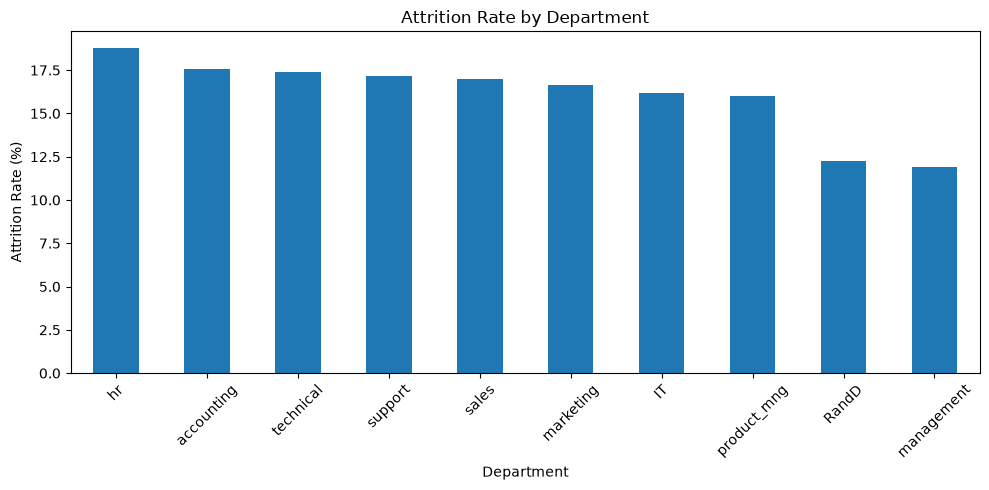

In [42]:
department_attrition.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
salary_attrition = (
    emp_data1
    .groupby('salary')['left']
    .mean()
    .sort_values(ascending=False)
    * 100
)

salary_attrition

salary
low       20.452962
medium    14.616993
high       4.848485
Name: left, dtype: float64

<Axes: ylabel='Frequency'>

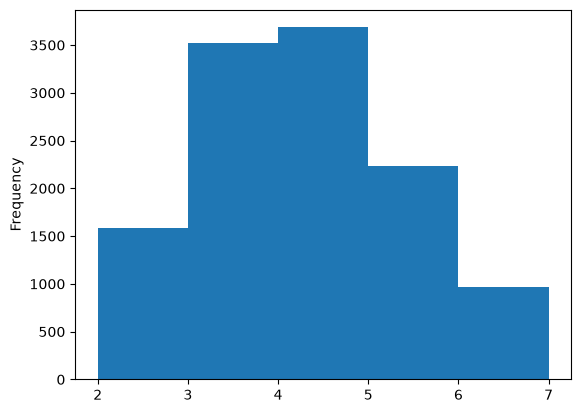

In [44]:
emp_data1['number_project'].plot(kind = 'hist', bins=5)

<Axes: ylabel='Frequency'>

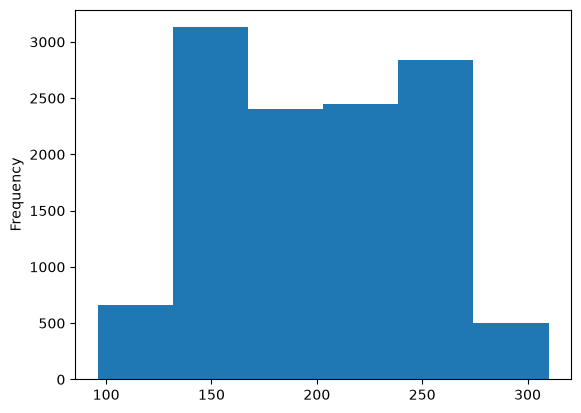

In [45]:
emp_data1['average_montly_hours'].plot(kind = 'hist', bins=6)

<Axes: ylabel='Frequency'>

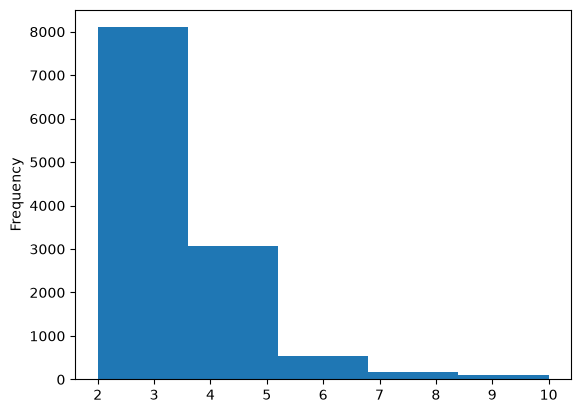

In [46]:
emp_data1['time_spend_company'].plot(kind = 'hist', bins=5)

<Axes: ylabel='Frequency'>

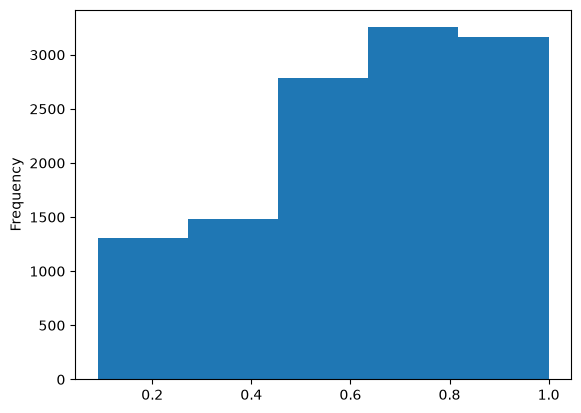

In [47]:
emp_data1['satisfaction_level'].plot(kind = 'hist', bins=5)

<Axes: ylabel='Frequency'>

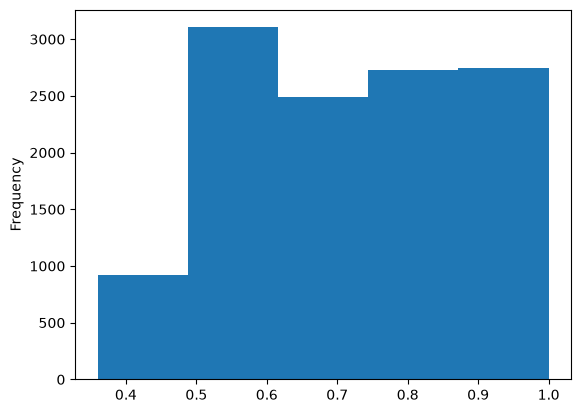

In [48]:
emp_data1['last_evaluation'].plot(kind = 'hist', bins=5)

In [49]:
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [50]:
emp_ml = pd.get_dummies(
    emp_data,
    columns=['Department', 'salary'],
    drop_first=True
)

In [51]:
emp_data1['salary'] = label_encoder.fit_transform(emp_data1['salary'])

emp_data1['Department'] = label_encoder.fit_transform(emp_data1['Department'])


In [52]:
x = emp_data1.drop('left', axis = 1)
y = emp_data1['left']

In [53]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    
)

In [54]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

In [55]:


xtrain_scaled = std_scaler.fit_transform(x_train)
xtest_scaled = std_scaler.transform(x_test)

In [56]:
xtrain_scaled
xtest_scaled

array([[-2.22616534,  0.4312433 ,  1.89275291, ..., -0.13311211,
         0.39533766, -0.56181526],
       [ 0.4636721 ,  1.44221642,  0.17048512, ..., -0.13311211,
         0.74073148,  1.0287786 ],
       [ 0.7533469 ,  1.50168543,  0.17048512, ..., -0.13311211,
         0.39533766, -0.56181526],
       ...,
       [ 0.7533469 , -0.34185379, -0.69064878, ..., -0.13311211,
         0.39533766,  1.0287786 ],
       [ 0.29814364,  1.56115444,  0.17048512, ..., -0.13311211,
        -0.29544999, -0.56181526],
       [ 0.09123307, -0.10397776, -0.69064878, ..., -0.13311211,
         0.74073148, -0.56181526]], shape=(2399, 9))

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
Random_forest_model = RandomForestClassifier

In [59]:
from sklearn.ensemble import RandomForestClassifier

# Create model
Random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model
Random_forest_model.fit(x_train, y_train)

# Predictions
y_pred= Random_forest_model.predict(x_test)

In [60]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)                      

[[1991    7]
 [  39  362]]


<Axes: >

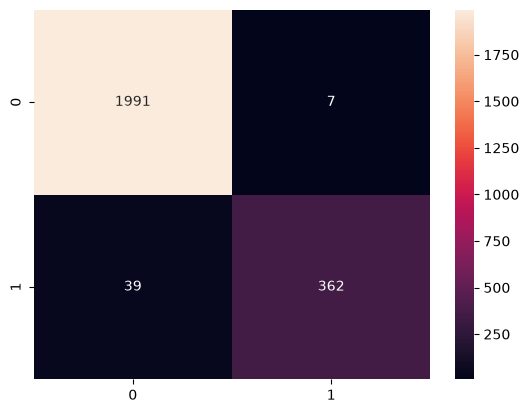

In [61]:
sns.heatmap(cm, annot = True, fmt = 'd')

In [62]:
from sklearn.metrics import accuracy_score
model_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the model = ", model_accuracy)  

Accuracy of the model =  0.9808253438932889


In [63]:
from sklearn.metrics import recall_score
model_recall = recall_score(y_test, y_pred)
print("recall score of the model = ", model_recall)  

recall score of the model =  0.9027431421446384


In [64]:
from sklearn.metrics import precision_score
model_precision = precision_score(y_test, y_pred)
print("precision score of the model = ", model_precision
     ) 

precision score of the model =  0.981029810298103


In [65]:
from sklearn.metrics import f1_score
f1score = f1_score(y_test, y_pred)
print("f1 score of the model = ", f1score
     ) 

f1 score of the model =  0.9402597402597402


In [66]:
from sklearn.metrics import classification_report
model_precision = classification_report
(y_test, y_pred)

(397      1
 3107     0
 9331     0
 357      1
 1326     1
         ..
 9322     0
 10440    0
 3077     0
 6113     0
 3794     0
 Name: left, Length: 2399, dtype: int64,
 array([1, 0, 0, ..., 0, 0, 0], shape=(2399,)))

In [67]:
score_list = Random_forest_model.feature_importances_

list_of_features = list(x.columns)

score_df = pd.DataFrame({
    "Feature": list_of_features,
    "score": score_list
})

score_df = score_df.sort_values(
    by='score',
    ascending=False
)

score_df

,Feature,score
0,satisfaction_level,0.358597
2,number_project,0.176914
4,time_spend_company,0.172132
3,average_montly_hours,0.153126
1,last_evaluation,0.113928
7,Department,0.012502
8,salary,0.007802
5,Work_accident,0.004296
6,promotion_last_5years,0.000704


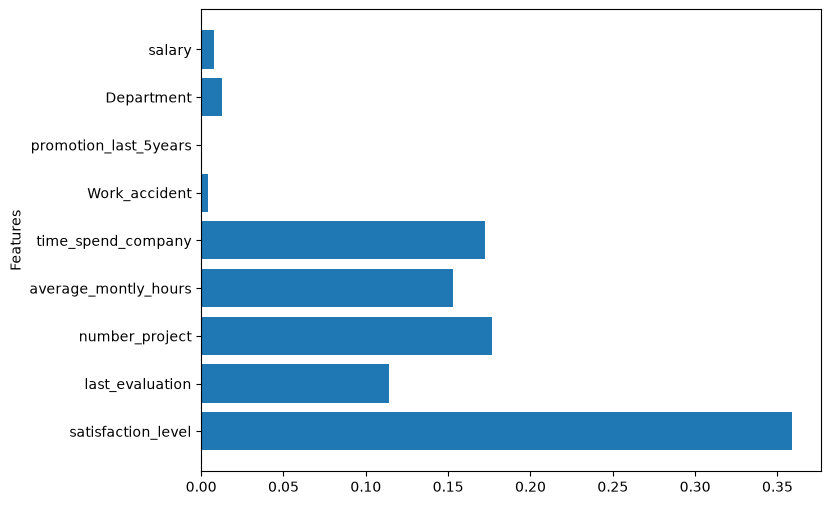

In [68]:
list_of_features = list(x.columns)

plt.figure(figsize=(8,6))

plt.barh(
    range(len(list_of_features)),
    Random_forest_model.feature_importances_
)

plt.yticks(
    np.arange(len(list_of_features)),
    list_of_features
)

plt.ylabel('Features')

plt.show()

In [69]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    Random_forest_model,
    xtrain_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores =", scores)
print("Mean cross-validation score =", scores.mean())

Cross-validation scores = [0.9885357  0.98332465 0.98488008 0.98592284 0.98748697]
Mean cross-validation score = 0.9860300458452629


In [70]:
Avg_model_score = scores.mean()
print("Average model score = ", Avg_model_score)

Average model score =  0.9860300458452629


In [71]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [72]:
parameters = {
    'n_rdtimators' : [50,100],
    'max_features' : ['sqrt', 'log2', None]}

In [73]:
grid_search = GridSearchCV(estimator = Random_forest_model, param_grid = parameters)

In [74]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [75]:
grid_search = GridSearchCV(
    estimator=Random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(xtrain_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",

In [76]:
Random_forest_model_new = RandomForestClassifier(max_features='log2', n_estimators= 100)

In [77]:
Random_forest_model_new.fit(xtrain_scaled, y_train)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    Random_forest_model_new,
    xtrain_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores =", scores)

Cross-validation scores = [0.9885357  0.98228244 0.98488008 0.98592284 0.98748697]


In [82]:
Avg_Model_score = scores.mean()
print('average model score = ', Avg_Model_score)

average model score =  0.9858216039484416
